# Week 2 Assignment - End-to-End Machine Learning Pipeline

## 1. Import Required Libraries

This section imports the Python libraries needed throughout the assignment for data analysis, visualization, machine learning, and forecasting.

In [23]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.stattools import adfuller

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load the Dataset

The dataset is loaded into a pandas DataFrame. Its shape, column names, data types, and summary statistics are checked to get a quick overview of the dataset before moving to preprocessing and analysis.

In [2]:
df = pd.read_csv("data/tesla_deliveries_dataset_2015_2025.csv")

print("Shape:", df.shape)
print("\nColumns:\n", df.columns)

df.info()

df.describe().T

Shape: (2640, 12)

Columns:
 Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   str    
 3   Model                 2640 non-null   str    
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non

,count,mean,std,min,25%,50%,75%,max
Year,2640.0,2020.000000,3.162877,2015.00,2017.000,2020.000,2023.0000,2025.00
Month,2640.0,6.500000,3.452707,1.00,3.750,6.500,9.2500,12.00
Estimated_Deliveries,2640.0,9922.199621,3935.950093,48.00,7292.000,9857.000,12510.2500,25704.00
Production_Units,2640.0,10655.847348,4260.600858,50.00,7828.250,10546.500,13469.0000,28939.00
Avg_Price_USD,2640.0,84907.340330,20123.258036,50003.70,67726.365,85058.510,102373.0425,119965.36
Battery_Capacity_kWh,2640.0,87.059470,20.836265,60.00,75.000,82.000,100.0000,120.00
Range_km,2640.0,500.257576,120.868549,330.00,418.000,470.000,586.2500,719.00
CO2_Saved_tons,2640.0,744.076989,353.221224,3.07,499.620,699.515,943.7650,2548.55
Charging_Stations,2640.0,8932.133712,3469.565883,3002.00,5897.750,8901.500,11938.0000,14996.00


## 3. Data Quality Check

Before moving to feature engineering and model building, the dataset is checked for missing values and duplicate records. This helps confirm that the data is complete and does not require any cleaning before analysis.

In [3]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

print("-" * 50)

# Check duplicate rows
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Missing Values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64
--------------------------------------------------
Duplicate Rows: 0


#### Observation
No missing values or duplicate rows were found in the dataset. Since the data is already clean, no additional preprocessing was needed at this stage, and the dataset was ready for exploratory analysis and feature engineering.

## 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the patterns and relationships present in the Tesla deliveries dataset. The visualizations below help analyze deliveries across different models and regions, examine relationships between variables, and identify important trends before building machine learning models.

### 4.1 Estimated Deliveries by Model

This bar chart compares the total estimated deliveries for each Tesla model. It gives a quick overview of which models contribute the most to the overall delivery count.

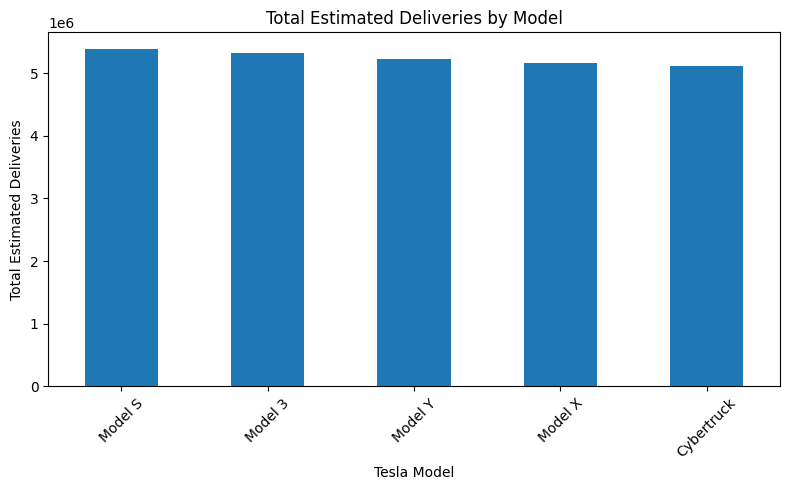

In [4]:
# Total Estimated Deliveries by Model

model_deliveries = (
    df.groupby("Model")["Estimated_Deliveries"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

model_deliveries.plot(kind="bar")

plt.title("Total Estimated Deliveries by Model")
plt.xlabel("Tesla Model")
plt.ylabel("Total Estimated Deliveries")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Observation

**Model S** records the highest estimated deliveries, followed closely by **Model 3**. The remaining models have similar delivery counts, indicating that deliveries are fairly balanced across Tesla's vehicle lineup.

### 4.2 Estimated Deliveries by Region

This chart shows the total estimated deliveries across different regions, making it easier to compare Tesla's regional performance.

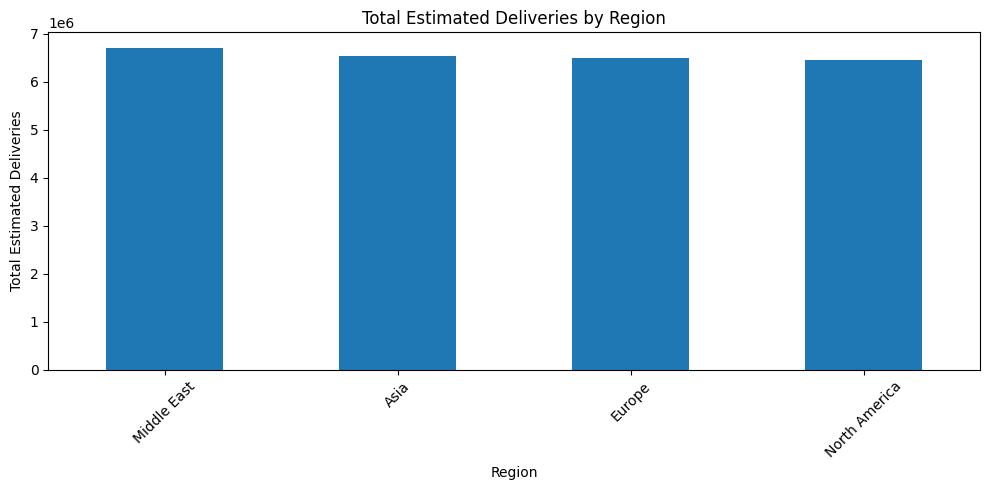

In [5]:
# Total Estimated Deliveries by Region

region_deliveries = (
    df.groupby("Region")["Estimated_Deliveries"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

region_deliveries.plot(kind="bar")

plt.title("Total Estimated Deliveries by Region")
plt.xlabel("Region")
plt.ylabel("Total Estimated Deliveries")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Observation

The bar chart shows that estimated deliveries vary across different regions. While a few regions contribute more deliveries, the differences are not extremely large. This gives a clear picture of Tesla's regional distribution of estimated deliveries.

### 4.3 Correlation Heatmap

The correlation heatmap is used to examine how the numerical features are related to each other. Correlation values range from -1 to +1, where values closer to **+1** indicate a strong positive relationship, values near -1 indicate a strong negative relationship, and values around **0** indicate little or no linear relationship.

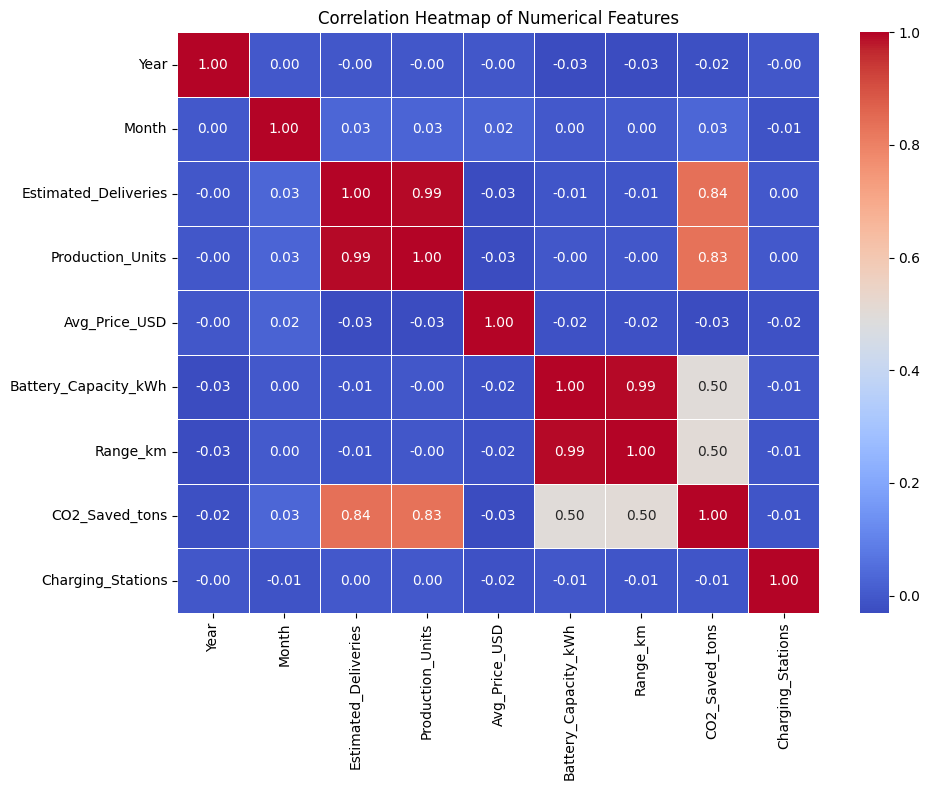

In [6]:
# Correlation Heatmap

plt.figure(figsize=(10, 8))

numeric_df = df.select_dtypes(include=["number"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

#### Observation

The correlation heatmap shows a **very strong positive correlation (0.99)** between **Production_Units** and **Estimated_Deliveries**, meaning that higher production is closely associated with higher estimated deliveries. It also shows a strong positive correlation (0.99) between **Battery_Capacity_kWh** and **Range_km**, indicating that vehicles with larger battery capacities generally offer longer driving ranges.

### 4.4 Production Units vs Estimated Deliveries

This scatter plot compares Production_Units with Estimated_Deliveries to examine their relationship. A clear upward pattern would indicate that higher production is associated with higher estimated deliveries.

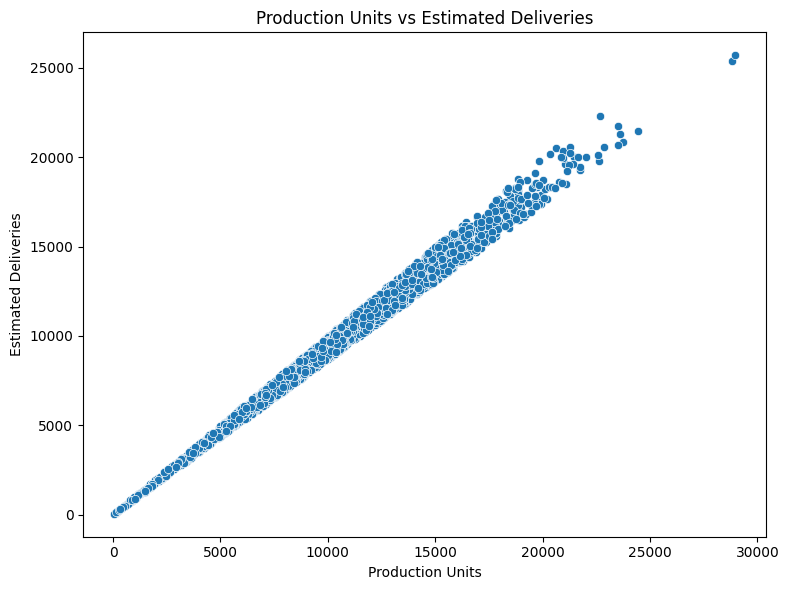

In [7]:
# Production Units vs Estimated Deliveries

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Production_Units",
    y="Estimated_Deliveries"
)

plt.title("Production Units vs Estimated Deliveries")
plt.xlabel("Production Units")
plt.ylabel("Estimated Deliveries")

plt.tight_layout()
plt.show()

#### Observation

The scatter plot shows a strong positive linear relationship between **Production_Units** and **Estimated_Deliveries**. Most data points are closely aligned along an upward trend, indicating that higher production is associated with higher estimated deliveries. This observation is consistent with the strong positive correlation (0.99) seen in the heatmap.

### 4.5 Estimated Deliveries Over Time
This line chart shows how Tesla's estimated deliveries change over time. It helps identify overall trends and month-to-month fluctuations in deliveries throughout the dataset.

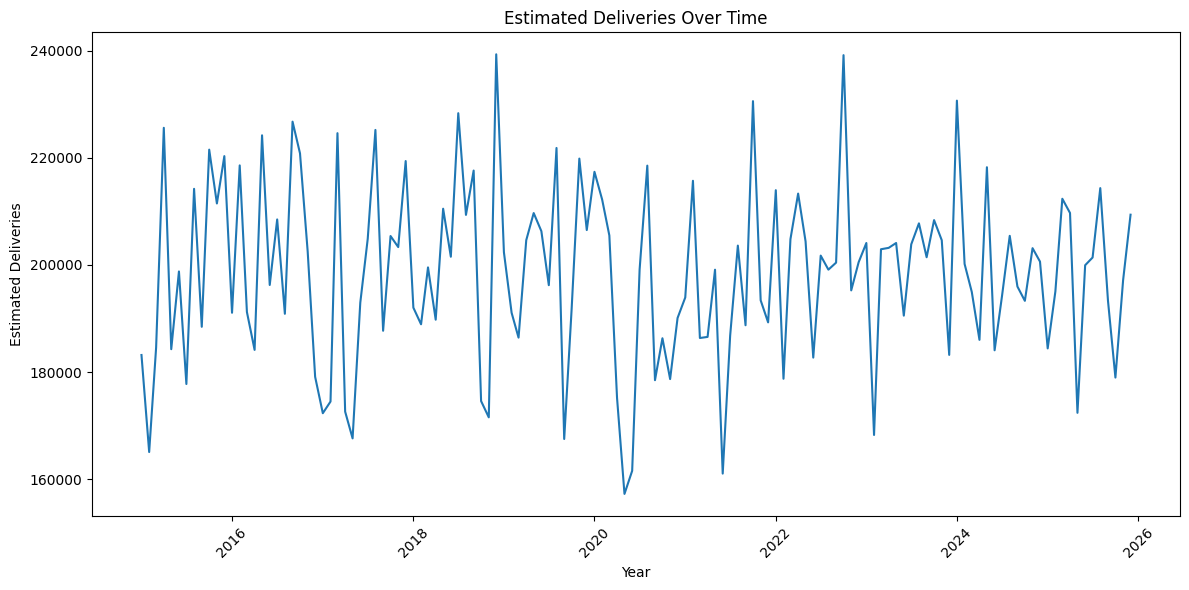

In [8]:
# Create Date column

df["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" + df["Month"].astype(str)
)

# Monthly total deliveries

monthly_deliveries = (
    df.groupby("Date")["Estimated_Deliveries"]
      .sum()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    x=monthly_deliveries.index,
    y=monthly_deliveries.values
)

plt.title("Estimated Deliveries Over Time")
plt.xlabel("Year")
plt.ylabel("Estimated Deliveries")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Observation

The time-series plot shows that estimated deliveries fluctuate throughout the observed period, generally ranging between **160,000** and **240,000** per month. Although there are several noticeable peaks and dips, there is no clear long-term upward or downward trend, indicating that delivery volumes remain relatively stable over time.

## 5. Feature Engineering

This step prepares the dataset for model training by converting categorical variables into numerical values and generating additional features. The newly created lag and rolling mean features help incorporate information from previous delivery records.

In [9]:
# Encode categorical variables

label_encoder = LabelEncoder()

categorical_columns = ["Region", "Model", "Source_Type"]

for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

# Create Lag Feature
df["Deliveries_Lag1"] = df["Estimated_Deliveries"].shift(1)

df["Deliveries_Lag1"] = df["Deliveries_Lag1"].fillna(
    df["Deliveries_Lag1"].mean()
)

# Create Rolling Mean Feature
df["Rolling_Mean_3"] = (
    df["Estimated_Deliveries"]
      .rolling(window=3)
      .mean()
)

df["Rolling_Mean_3"] = df["Rolling_Mean_3"].fillna(
    df["Rolling_Mean_3"].mean()
)

print(df[[
    "Estimated_Deliveries",
    "Deliveries_Lag1",
    "Rolling_Mean_3"
]].head())

print("Missing values in Deliveries_Lag1:", df["Deliveries_Lag1"].isna().sum())
print("Missing values in Rolling_Mean_3:", df["Rolling_Mean_3"].isna().sum())

   Estimated_Deliveries  Deliveries_Lag1  Rolling_Mean_3
0                 17646      9924.959454     9923.677407
1                  3797     17646.000000     9923.677407
2                  8411      3797.000000     9951.333333
3                  6555      8411.000000     6254.333333
4                 12374      6555.000000     9113.333333
Missing values in Deliveries_Lag1: 0
Missing values in Rolling_Mean_3: 0


#### Observation

The categorical columns **Region**, **Model**, and **Source_Type** were encoded using Label Encoding. Two additional features, **Deliveries_Lag1** and **Rolling_Mean_3**, were created to include information from previous delivery values. Any missing values generated during feature creation were filled with the column mean, leaving no missing values in the engineered features.

## 6. Linear Regression Model

The dataset is divided into 80% training and 20% testing data while preserving the original time order. A chronological split is used instead of a random split so that earlier records are used for training and later records for testing. A Linear Regression model is then trained, and its performance is evaluated using MAE, RMSE, and R² score.

In [10]:
# Select Features and Target

X = df.drop(columns=["Estimated_Deliveries", "Date"])
y = df["Estimated_Deliveries"]

# Chronological 80-20 Split

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 2112
Testing Samples: 528


In [11]:
# Train Linear Regression Model

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)

In [12]:
# Model Evaluation

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R² Score : {r2:.4f}")

MAE  : 310.33
RMSE : 375.56
R² Score : 0.9908


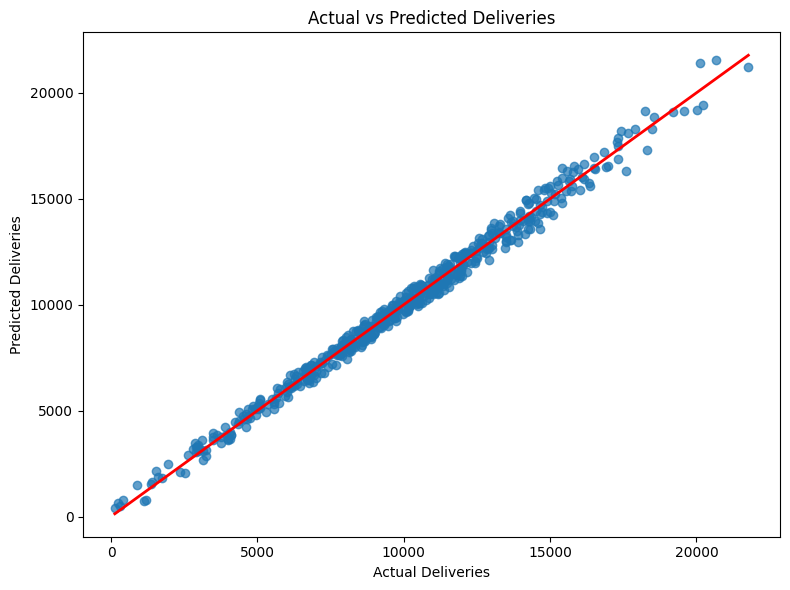

In [13]:
# Actual vs Predicted

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.title("Actual vs Predicted Deliveries")
plt.xlabel("Actual Deliveries")
plt.ylabel("Predicted Deliveries")

plt.tight_layout()
plt.show()

#### Observation

The Linear Regression model achieved an **R² score of 0.9908**, showing that it predicts estimated deliveries with high accuracy.

## 7. 5-Fold Cross Validation

To further validate the Linear Regression model, **5-fold cross-validation** is performed. The dataset is split into five folds, and the model is evaluated on each fold. The resulting scores help check whether the model performs consistently across different subsets of the data.

In [14]:
# 5-Fold Cross Validation

kf = KFold(
    n_splits=5,
    shuffle=False
)

cv_scores = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=kf,
    scoring="r2"
)

print("R² Score for each Fold:\n")

for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print("\nMean R² :", cv_scores.mean())
print("Std Dev :", cv_scores.std())

R² Score for each Fold:

Fold 1: 0.9906
Fold 2: 0.9905
Fold 3: 0.9895
Fold 4: 0.9905
Fold 5: 0.9908

Mean R² : 0.9903849476659861
Std Dev : 0.0004615353092553957


#### Observation

The R² scores remain close to 0.99 across all five folds, with a mean score of 0.9904 and a very small standard deviation (0.00046). This shows that the Linear Regression model performs consistently and its accuracy does not change significantly across different folds of the dataset.

## 8. Random Forest Regression with GridSearchCV

In this step, a Random Forest Regressor is trained to compare its performance with the Linear Regression model. GridSearchCV is used to test different values of the model's parameters and select the combination that gives the best cross-validation score.

In [15]:
# Hyperparameter Grid

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10, None]
}

# GridSearchCV

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': None, 'n_estimators': 50}


In [16]:
# Best Random Forest Model

best_rf = grid_search.best_estimator_

rf_predictions = best_rf.predict(X_test)

In [17]:
# Random Forest Evaluation

rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

rf_r2 = r2_score(y_test, rf_predictions)

print(f"MAE  : {rf_mae:.2f}")
print(f"RMSE : {rf_rmse:.2f}")
print(f"R² Score : {rf_r2:.4f}")

MAE  : 303.86
RMSE : 388.55
R² Score : 0.9902


#### Observation

The optimized Random Forest model obtained an **R² score of 0.9902** with low prediction errors, indicating strong predictive performance.

In [18]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, rf_mae],
    "RMSE": [rmse, rf_rmse],
    "R² Score": [r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,310.334522,375.564666,0.990806
1,Random Forest,303.858333,388.551276,0.990159


#### Observation

Both models achieved R² scores above 0.99, indicating very similar performance. Random Forest recorded a slightly lower MAE, whereas Linear Regression achieved a marginally **higher R² score** and **lower RMSE**. Overall, both models performed well, with only small differences in their prediction accuracy.

### 8.1 Feature Importance

This section examines which features have the greatest influence on the Random Forest model. Higher importance scores indicate that a feature contributes more to predicting estimated deliveries.

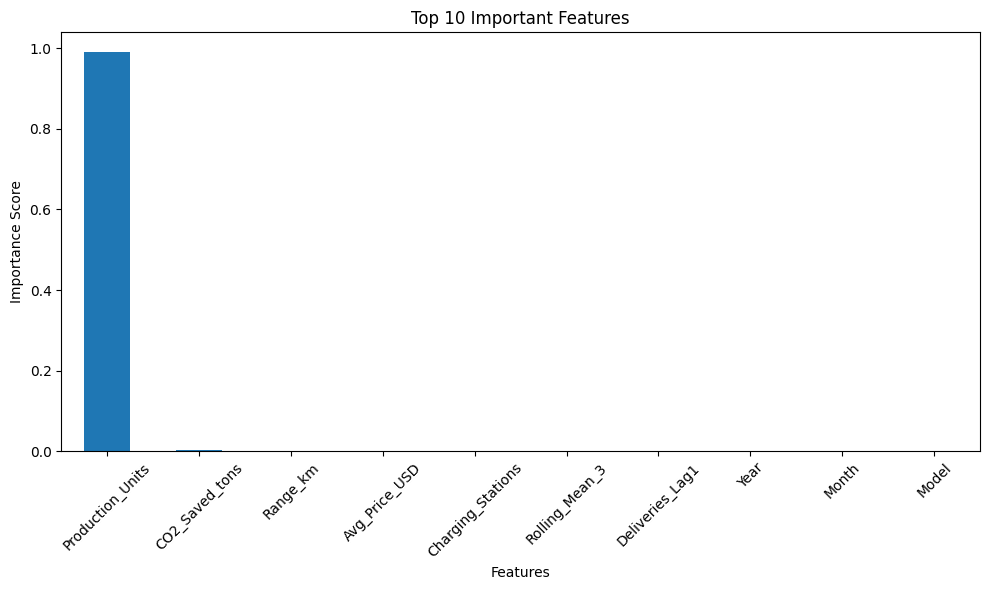

In [19]:
# Feature Importance

feature_importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))

feature_importance.head(10).plot(kind="bar")

plt.title("Top 10 Important Features")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Observation

The feature importance plot shows that **Production_Units** has the highest importance score by a large margin. All other features have comparatively small contributions, suggesting that production units have the strongest influence on the predicted delivery values in this dataset.

## 9. Augmented Dickey-Fuller (ADF) Stationarity Test

The Augmented Dickey-Fuller (ADF) test is used to determine whether a time series is stationary.

- Null Hypothesis (H₀): The time series is non-stationary.
- Alternative Hypothesis (H₁): The time series is stationary.

In this notebook, the ADF test is applied to check whether the Estimated_Deliveries time series is stationary. A p-value below 0.05 indicates that the series can be treated as stationary.

In [22]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["Estimated_Deliveries"])

print("ADF Statistic :", result[0])
print("P-value :", result[1])
if result[1] < 0.05:
    print("Conclusion: Reject the null hypothesis.")
    print("The Estimated_Deliveries time series is stationary.")
else:
    print("Conclusion: Fail to reject the null hypothesis.")
    print("The Estimated_Deliveries time series is non-stationary.")
    
print("\nCritical Values:")
for key, value in result[4].items():
    print(f"{key}: {value:.4f}")

ADF Statistic : -53.82661259715622
P-value : 0.0
Conclusion: Reject the null hypothesis.
The Estimated_Deliveries time series is stationary.

Critical Values:
1%: -3.4328
5%: -2.8626
10%: -2.5674


#### Observation

The ADF test returned a p-value of **0.0**, which is below **0.05**. Therefore, the null hypothesis is rejected, indicating that the **Estimated_Deliveries** series is **stationary**. This means the series does not show evidence of non-stationarity and can be used for further time-series analysis.

## 10. Forecast Table

This table compares the actual delivery values with the predictions from the Linear Regression model. It also calculates the percentage error for each prediction to show how closely the predicted values match the actual values.

In [21]:
forecast = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

forecast["Error %"] = (
    abs(forecast["Actual"] - forecast["Predicted"])
    / forecast["Actual"]
) * 100

forecast.head(20)

,Actual,Predicted,Error %
0,11974,11350.249894,5.209204
1,9189,8960.226206,2.489648
2,15956,16390.011572,2.720052
3,10336,10882.323750,5.285640
4,15152,15223.636066,0.472783
5,4224,4453.460471,5.432303
6,8475,8766.438567,3.438803
7,4093,3851.878984,5.891058
8,2972,3385.900162,13.926654
9,8208,8209.196553,0.014578


#### Observation

The forecast table shows that the predicted delivery values are very close to the actual values, with most percentage errors remaining below 6%. This indicates that the Linear Regression model makes accurate predictions and performs consistently on the test dataset.

## 11. Conclusion

This assignment demonstrated a complete machine learning workflow using the Tesla deliveries dataset. After inspecting and exploring the data, new features were created to improve model performance. Both Linear Regression and Random Forest achieved R² scores above 0.99, indicating highly accurate predictions. Feature importance analysis identified Production_Units as the most influential variable, while the ADF test confirmed that the delivery series is stationary. Overall, the project highlights the importance of data exploration, feature engineering, and model evaluation when building reliable predictive models.